In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')
sns.set_theme(style="whitegrid")

In [4]:
df = pd.read_csv("Groceries_dataset.csv")

In [5]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [8]:
df['BasketID'] = df['Member_number'].astype(str) + '_' + df['Date'].astype(str)
df.head()


,Member_number,Date,itemDescription,BasketID
0,1808,2015-07-21,tropical fruit,1808_2015-07-21
1,2552,2015-01-05,whole milk,2552_2015-01-05
2,2300,2015-09-19,pip fruit,2300_2015-09-19
3,1187,2015-12-12,other vegetables,1187_2015-12-12
4,3037,2015-02-01,whole milk,3037_2015-02-01


In [9]:
basket_size = df.groupby('BasketID')['itemDescription'].count()
basket_size.head()

BasketID
1000_2014-06-24    3
1000_2015-03-15    4
1000_2015-05-27    2
1000_2015-07-24    2
1000_2015-11-25    2
Name: itemDescription, dtype: int64

In [10]:
basket_size.describe()

count    14963.000000
mean         2.590724
std          1.117469
min          2.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         11.000000
Name: itemDescription, dtype: float64

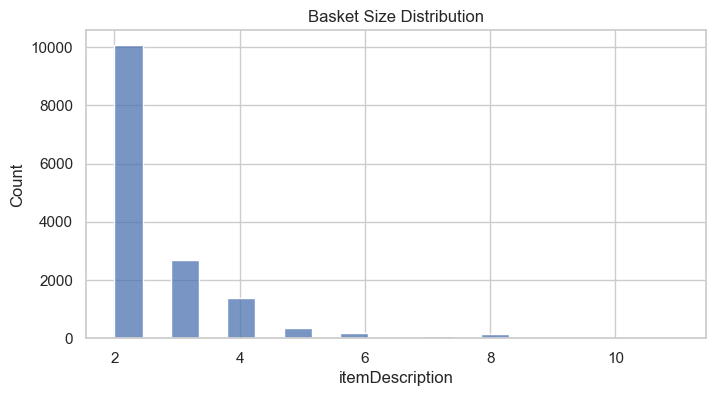

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(basket_size, bins=20)
plt.title("Basket Size Distribution")
plt.show()

In [16]:
frequency = df.groupby('Member_number')['Date'].nunique()
frequency.head()

Member_number
1000    5
1001    5
1002    4
1003    4
1004    8
Name: Date, dtype: int64

In [17]:
def freq_segment(x):
    if x == 1:
        return "1 visit"
    elif 2 <= x <= 5:
        return "2-5 visits"
    elif 6 <= x <= 10:
        return "6-10 visits"
    else:
        return "10+ visits"
freq_segmented = frequency.apply(freq_segment)
freq_segmented.value_counts()

Date
2-5 visits     2819
6-10 visits     725
1 visit         349
10+ visits        5
Name: count, dtype: int64

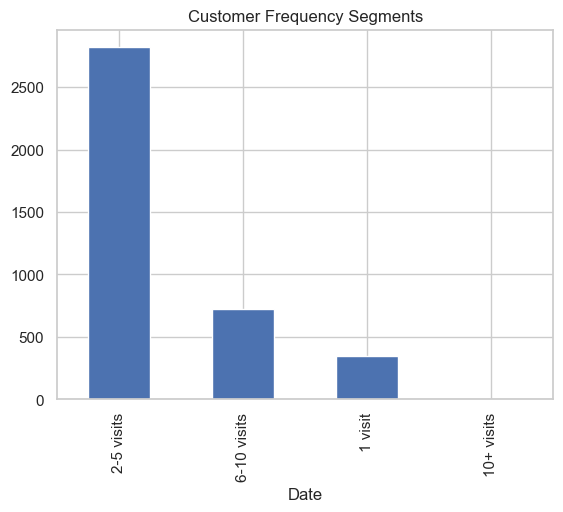

In [18]:
freq_segmented.value_counts().plot(kind='bar')
plt.title("Customer Frequency Segments")
plt.show()

In [19]:
top_products = df['itemDescription'].value_counts().head(20)
top_products

itemDescription
whole milk            2502
other vegetables      1898
rolls/buns            1716
soda                  1514
yogurt                1334
root vegetables       1071
tropical fruit        1032
bottled water          933
sausage                924
citrus fruit           812
pastry                 785
pip fruit              744
shopping bags          731
canned beer            717
bottled beer           687
whipped/sour cream     662
newspapers             596
frankfurter            580
brown bread            571
pork                   566
Name: count, dtype: int64

In [20]:
df['Weekday'] = df['Date'].dt.day_name()
df['Weekday'].value_counts()

Weekday
Thursday     5620
Friday       5562
Wednesday    5562
Tuesday      5558
Saturday     5551
Sunday       5530
Monday       5382
Name: count, dtype: int64

In [21]:
df['BasketID'] = df['Member_number'].astype(str) + '_' + df['Date'].astype(str)
basket_day = df.groupby('Weekday')['BasketID'].nunique()
basket_day

Weekday
Friday       2136
Monday       2067
Saturday     2161
Sunday       2138
Thursday     2188
Tuesday      2142
Wednesday    2131
Name: BasketID, dtype: int64

In [22]:
avg_basket_day = df.groupby('Weekday')['itemDescription'].count() / df.groupby('Weekday')['BasketID'].nunique()
avg_basket_day

Weekday
Friday       2.603933
Monday       2.603774
Saturday     2.568718
Sunday       2.586529
Thursday     2.568556
Tuesday      2.594771
Wednesday    2.610042
dtype: float64

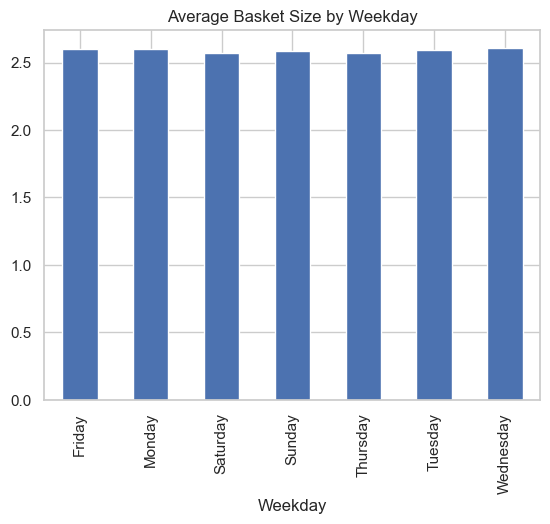

In [23]:
avg_basket_day.plot(kind='bar')
plt.title("Average Basket Size by Weekday")
plt.show()

In [25]:
from itertools import combinations
from collections import Counter
basket_items = df.groupby('BasketID')['itemDescription'].apply(list)
pair_counts = Counter()
for items in basket_items:
    for pair in combinations(items, 2):
        pair_counts[pair] += 1
pair_counts.most_common(10) #bonus

[(('whole milk', 'whole milk'), 148),
 (('whole milk', 'rolls/buns'), 143),
 (('sausage', 'whole milk'), 131),
 (('other vegetables', 'whole milk'), 130),
 (('whole milk', 'soda'), 128),
 (('whole milk', 'yogurt'), 126),
 (('whole milk', 'other vegetables'), 113),
 (('other vegetables', 'rolls/buns'), 112),
 (('tropical fruit', 'whole milk'), 101),
 (('other vegetables', 'soda'), 95)]

In [ ]:
top_customers = df.groupby('Member_number')['BasketID'].nunique().sort_values(ascending=False).head(10)
top_customers #bonus

Member_number
2271    11
4338    11
3737    11
1379    11
2193    11
4376    10
4864    10
1410    10
3484    10
4217    10
Name: BasketID, dtype: int64